## Импорт библиотек и чтение csv

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.computational_functions import calc_sleep_hours
from src.preprocessing import encoding_columns

In [3]:
primary_df = pd.read_csv("../data/processed/cleaned_and_encoded.csv", parse_dates=["date"])
primary_df.head(5)

,age,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,dream_colored,amount_of_coffee,...,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed,sleep_duration,sleep_hours,participant_id
0,45 лет и более,1,2026-09-13,0 days 23:30:00,0 days 06:45:00,3,3,1,color,1,...,0,4,2,1,0,3,1,0 days 07:15:00,7.250000,11
1,до 18 лет,1,2026-09-13,0 days 02:00:00,0 days 10:00:00,3,1,0,NaN,1,...,0,5,0,0,0,8,0,0 days 08:00:00,8.000000,19
2,от 18 до 30 лет,1,2026-09-13,0 days 00:00:00,0 days 08:13:00,4,0,0,NaN,0,...,0,2,4,0,0,8,1,0 days 08:13:00,8.216667,8
3,45 лет и более,0,2026-09-13,0 days 23:00:00,0 days 06:20:00,3,3,0,NaN,1,...,0,2,3,1,0,3,1,0 days 07:20:00,7.333333,17
4,от 18 до 30 лет,0,2026-09-13,0 days 03:00:00,0 days 10:25:00,5,0,1,color,10,...,1,2,1,0,1,3,1,0 days 07:25:00,7.416667,16


In [4]:
df = primary_df.copy()

df[["wake_up", "fall_asleep", "sleep_duration"]] = df[["wake_up", "fall_asleep", "sleep_duration"]].astype("timedelta64[us]")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype          
---  ------                      --------------  -----          
 0   age                         420 non-null    str            
 1   sex                         420 non-null    int64          
 2   date                        420 non-null    datetime64[us] 
 3   fall_asleep                 420 non-null    timedelta64[us]
 4   wake_up                     420 non-null    timedelta64[us]
 5   sleep_quality               420 non-null    int64          
 6   awakenings                  420 non-null    int64          
 7   dream_remembered            420 non-null    int64          
 8   dream_colored               187 non-null    str            
 9   amount_of_coffee            420 non-null    int64          
 10  amount_of_coffee_after16    420 non-null    int64          
 11  alcohol                     420 non-null    int64       

## Исследовательский анализ данных (EDA)

### Распределение и анализ переменной dream_colored

In [5]:
df["dream_colored"].value_counts(normalize=True)

dream_colored
color          0.802139
not_defined    0.133690
black-white    0.064171
Name: proportion, dtype: float64

In [6]:
dream_color_for_ages = df.groupby(by="age")["dream_colored"].value_counts().reset_index(name="count")
pivot_dream_color = dream_color_for_ages.pivot(index="age", columns="dream_colored", values="count")
pivot_dream_color

dream_colored,black-white,color,not_defined
age,,,
45 лет и более,10.0,27.0,14.0
до 18 лет,NaN,4.0,NaN
от 18 до 30 лет,2.0,112.0,11.0
от 30 до 45 лет,NaN,7.0,NaN


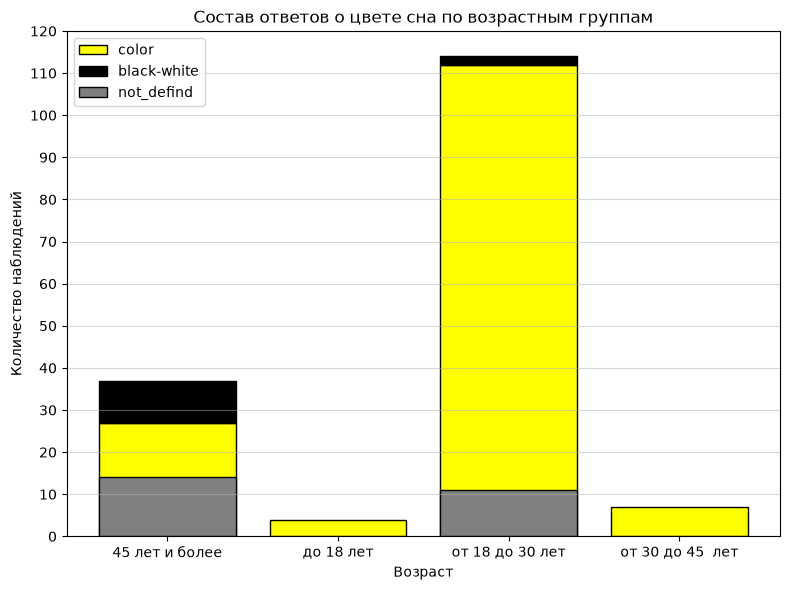

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(pivot_dream_color.index, pivot_dream_color["color"], color="yellow", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["black-white"], bottom=pivot_dream_color["color"], color="black", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["not_defined"], color="gray", edgecolor="black")

ax.set_title("Cостав ответов о цвете сна по возрастным группам")
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество наблюдений")

ax.set_yticks(range(0, 130, 10))

ax.grid(True, axis="y", alpha=0.5)

ax.legend(labels=["color", "black-white", "not_defind"])

plt.tight_layout()
plt.show()

Среди наблюдений с запомнившимся сном и определённым ответом о цвете доля цветных ответов составила 80%. В имеющейся выборке ответы о чёрно-белых снах чаще встречались у участников старшей возрастной группы. Из-за малого количества участников в этой группе нельзя делать устойчивый вывод о связи возраста и цветности снов.

### Доля запомненных сновидений по участникам

In [8]:
print("Доля запоминания сна у каждого участника, %")
shape_remembered = (df.groupby(by="participant_id")["dream_remembered"].mean() * 100).sort_values().reset_index(name="shape")
shape_remembered

Доля запоминания сна у каждого участника, %


,participant_id,shape
0,5,0.000000
1,12,0.000000
2,1,16.666667
3,21,16.666667
4,28,16.666667
5,38,16.666667
6,20,18.181818
7,19,25.000000
8,32,25.000000
9,2,25.000000


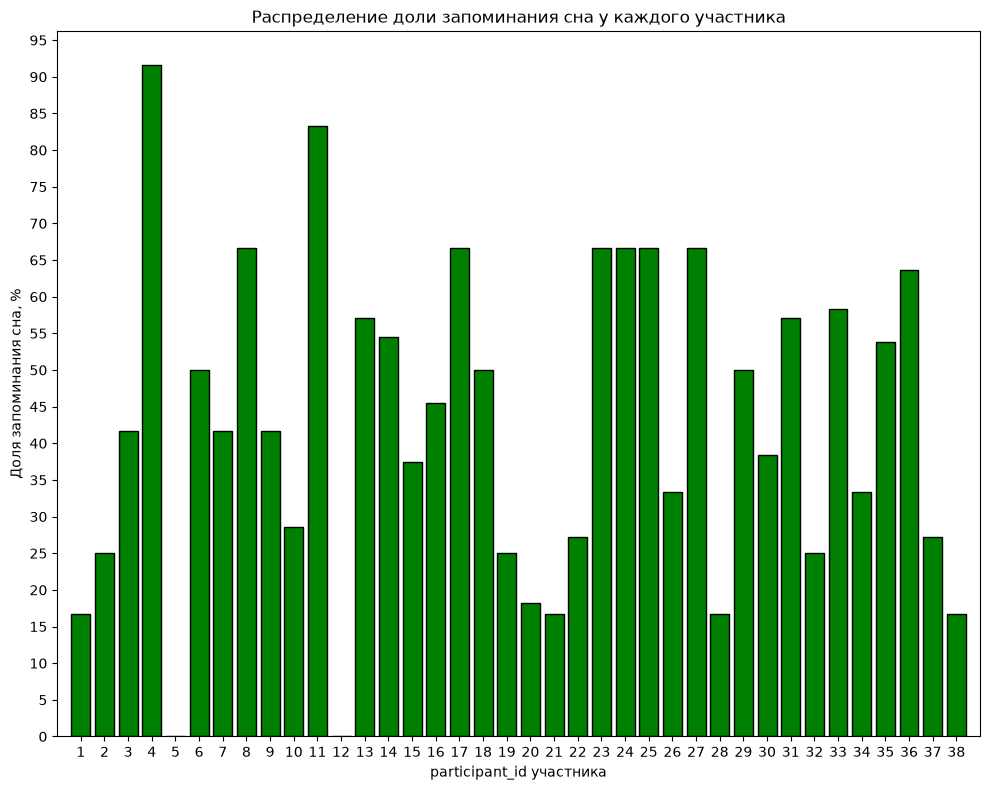

In [9]:
shape_remembered = shape_remembered.sort_values(by="participant_id")

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(shape_remembered["participant_id"], shape_remembered["shape"], color="green", edgecolor="black")

ax.set_title("Распределение доли запоминания сна у каждого участника")
ax.set_xlabel("participant_id участника")
ax.set_ylabel("Доля запоминания сна, %")

ax.set_xticks(range(1, len(shape_remembered["participant_id"]) + 1))
ax.set_xlim(0, len(shape_remembered["participant_id"]) + 1)

ax.set_yticks(range(0, 100, 5))

plt.tight_layout()
plt.show()

In [10]:
print(f"Максимальный процент запоминания снов у участника: {shape_remembered.max().round(1)}%")
print(f"Минимальный процент запоминания снов у участника: {shape_remembered.min().round(1)}%")

Максимальный процент запоминания снов у участника: participant_id    38.0
shape             91.7
dtype: float64%
Минимальный процент запоминания снов у участника: participant_id    1.0
shape             0.0
dtype: float64%


### Построение диаграммы boxplot для целевой переменной `dream_remembered` по всем наблюдениям.

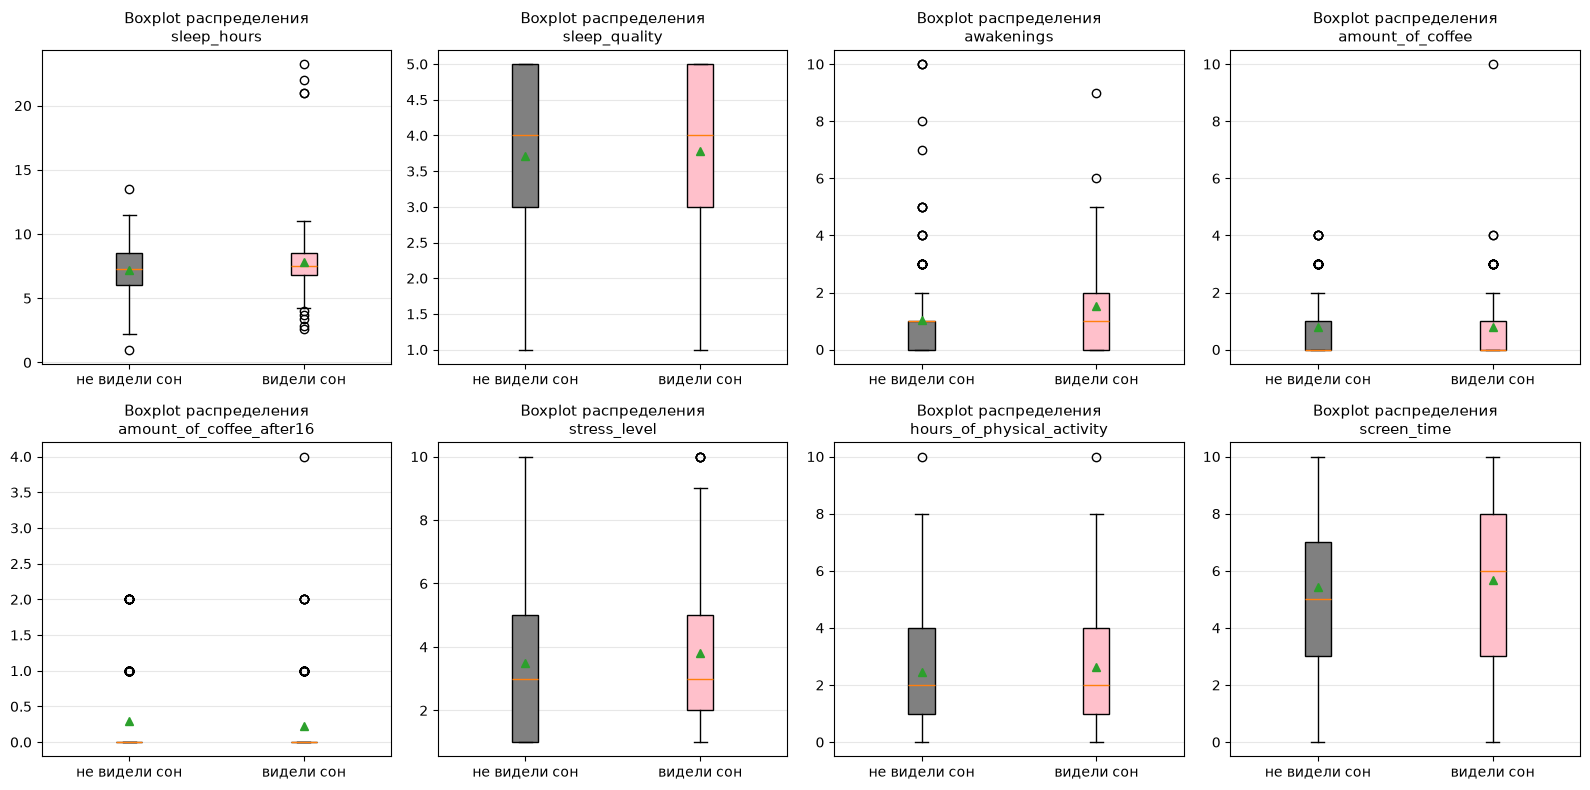

In [11]:
boxplot_cols = ['sleep_hours', 'sleep_quality', 'awakenings', 'amount_of_coffee', 'amount_of_coffee_after16', 'stress_level', 'hours_of_physical_activity', 'screen_time']

n = len(boxplot_cols)

fig, axes =  plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, i in zip(axes.flatten(), boxplot_cols):

    group_0 = df[df["dream_remembered"] == 0][i].values
    group_1 = df[df["dream_remembered"] == 1][i].values

    bp = ax.boxplot([group_0, group_1], tick_labels=["не видели сон", "видели сон"], showmeans=True, patch_artist=True)

    ax.set_title(f"Boxplot распределения\n{i}", fontsize=11)

    ax.grid(True, alpha=0.3, axis="y")

    bp["boxes"][0].set_facecolor("gray")
    bp["boxes"][1].set_facecolor("pink")

plt.tight_layout()
plt.show()

- sleep hours: Медиана у видевших сон немного выше - примерно 7,5 часа против 7–7,2 часа. Есть выбросы около 21–23 часов; их стоит проверить в исходных данных.
- awakenings: У видевших и невидевших сон медиана около 1 пробуждения. Разброс большой, много выбросов сверху, у людей не видевших сон
- stress_level: Медиана в обеих группах около 3. У видевших сон среднее выглядит немного выше, но распределения существенно перекрываются.
- screen_time: Медиана у видевших сон около 6 часов, у не видевших — около 5. При этом разброс в обеих группах широк
- в графиках sleep_quality, amount_of_coffe(_after16), hours_of_physical_activity между видевшими и невидевшими сон различия близки к минимуму

### Построение столбчатой ​​диаграммы для целевой переменной `dream_remembered` для бинарных признаков

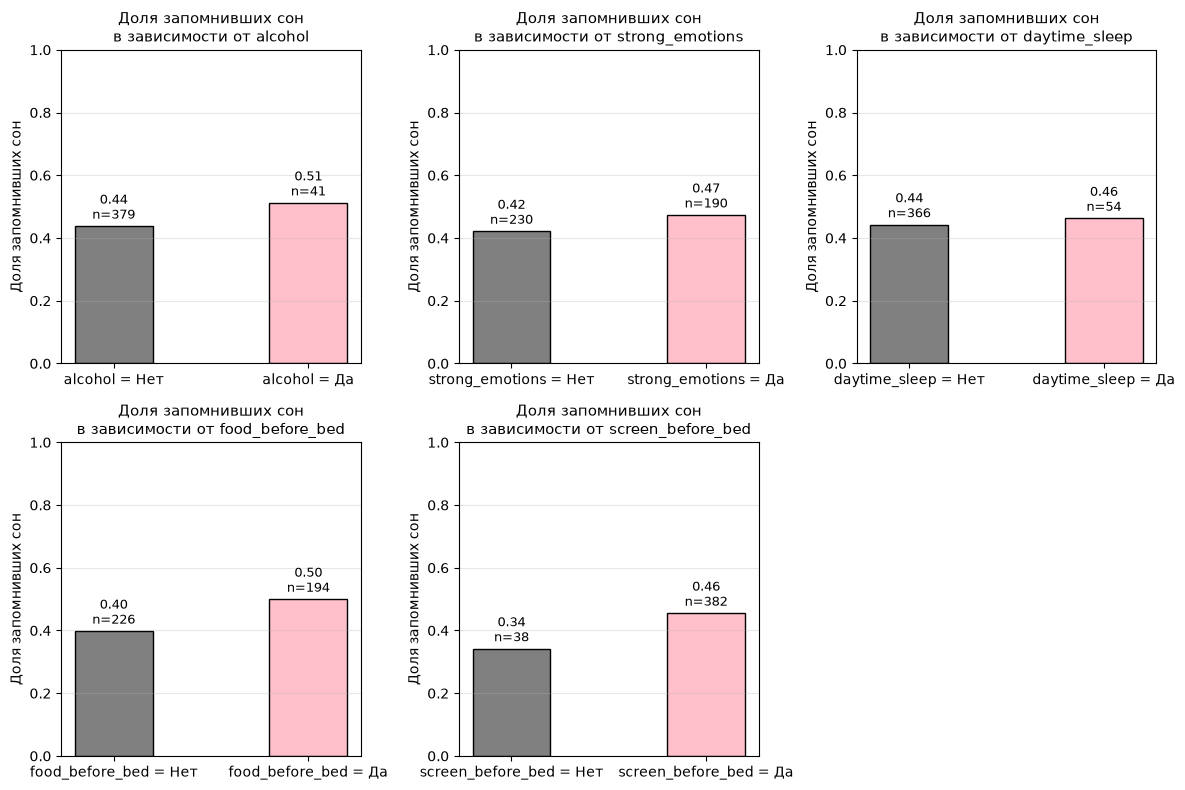

In [12]:
barchart_cols = ["alcohol", "strong_emotions", "daytime_sleep", "food_before_bed", "screen_before_bed"]
n = len(barchart_cols)

fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, col in zip(axes.flatten(), barchart_cols):
    grouped = df.groupby(col)["dream_remembered"].agg(["mean", "count"])

    labels = [f"{col} = Нет", f"{col} = Да"]

    bars = ax.bar(labels, grouped["mean"], color=["gray", "pink"], width=0.4, edgecolor="black")

    for bar, mean_val, count_val in zip(bars, grouped["mean"], grouped["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{mean_val:.2f}\nn={count_val}",
                ha="center", va="bottom", fontsize=9)

    ax.set_title(f"Доля запомнивших сон\nв зависимости от {col}", fontsize=11)
    ax.set_ylabel("Доля запомнивших сон")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis="y")

for ax in axes.flatten()[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

- alcohol: Доля несколько выше среди видевших сон
- strong_emotions: Разница незначительная
- daytime_sleep: Практически одинаковые доли
- food_before_bed: Разница около 10 процентных пунктов — одна из наиболее заметных на этих графиках
- screen_before_bed: Разница около 11 процентных пунктов — также одна из наиболее заметных

### Проверка выбросов и валидность данных для sleep_hours

In [13]:
# Проверка нижней границы выбросов
df[df["sleep_hours"] < 3]

,age,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,dream_colored,amount_of_coffee,...,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed,sleep_duration,sleep_hours,participant_id
25,от 18 до 30 лет,0,2026-09-13,0 days 05:00:00,0 days 07:30:00,2,0,0,NaN,0,...,1,3,7,0,1,2,0,0 days 02:30:00,2.500000,33
100,от 18 до 30 лет,1,2026-09-16,0 days 04:10:00,0 days 07:00:00,3,0,1,color,1,...,1,7,1,0,0,5,1,0 days 02:50:00,2.833333,37
101,от 18 до 30 лет,1,2026-09-16,0 days 04:52:00,0 days 07:34:00,2,0,0,NaN,1,...,1,1,1,0,0,5,1,0 days 02:42:00,2.700000,38
167,45 лет и более,1,2026-09-17,0 days 02:00:00,0 days 03:00:00,1,10,0,NaN,3,...,1,10,2,0,1,3,1,0 days 01:00:00,1.000000,36
232,45 лет и более,1,2026-09-19,0 days 00:01:00,0 days 02:36:00,3,2,1,black-white,3,...,0,3,6,0,0,3,1,0 days 02:35:00,2.583333,31
274,от 18 до 30 лет,1,2026-09-21,0 days 05:50:00,0 days 08:20:00,2,0,0,NaN,1,...,1,7,2,0,0,8,1,0 days 02:30:00,2.500000,37
281,от 18 до 30 лет,1,2026-09-21,0 days 04:57:00,0 days 07:50:00,3,0,0,NaN,2,...,0,1,0,0,0,4,1,0 days 02:53:00,2.883333,38
314,от 18 до 30 лет,1,2026-09-22,0 days 04:30:00,0 days 06:45:00,1,10,0,NaN,1,...,1,7,3,0,1,4,1,0 days 02:15:00,2.250000,15
384,от 18 до 30 лет,0,2026-09-24,0 days 05:00:00,0 days 07:50:00,1,0,0,NaN,0,...,0,7,3,0,1,10,1,0 days 02:50:00,2.833333,27


Данные по нижней границе выбросов корректны, но точные предположения о их достоверности гарантировать невозможно

In [14]:
# Проверка верхней границы выбросов
Q3 = df["sleep_hours"].describe()["75%"]
Q1 = df["sleep_hours"].describe()["25%"]
IQR = Q3- Q1
emission_limit = Q3 + 1.5 * IQR

print(f"Граница верхних выбросов: {emission_limit}")

Граница верхних выбросов: 11.75


In [15]:
df[df["sleep_hours"] > emission_limit][["participant_id", "fall_asleep", "wake_up", "sleep_hours"]]

,participant_id,fall_asleep,wake_up,sleep_hours
16,35,0 days 10:30:00,0 days 07:30:00,21.000000
39,35,0 days 10:25:00,0 days 07:26:00,21.016667
53,33,0 days 12:00:00,0 days 10:00:00,22.000000
230,3,0 days 00:55:00,0 days 00:09:00,23.233333
358,16,0 days 21:00:00,0 days 10:32:00,13.533333


- В первых 3-х записях - ошибка записи формата времени (12 часовой вместо 24 часового формата)
- В 4 записи некорректно отмечено время подъёма - (вместо 09:00 00:09)
- В последней записи выброс является корректным

*Так как невалидны только 4 записи, исправление корректно будет проводить вручную*

In [16]:
# Исправление первых 3-х наблюдений
df.loc[[16, 39], "fall_asleep"] += pd.Timedelta(hours=12)

df.loc[53, "fall_asleep"] -= pd.Timedelta(hours=12)

In [17]:
# Исправление 4 наблюдения
df.loc[230, "wake_up"] = pd.to_timedelta("09:00:00")

In [18]:
df = calc_sleep_hours(df)

#Проверка
df[df["sleep_hours"] > emission_limit][["participant_id", "fall_asleep", "wake_up", "sleep_hours"]]

,participant_id,fall_asleep,wake_up,sleep_hours
358,16,0 days 21:00:00,0 days 10:32:00,13.533333


In [19]:
df["sleep_hours"].describe()

count    420.000000
mean       7.332103
std        1.739585
min        1.000000
25%        6.333333
50%        7.366667
75%        8.500000
max       13.533333
Name: sleep_hours, dtype: float64

Исправление данных повело к исключению из выбросов. Теперь по верхней границе только 1 корректный выброс

### Корреляционный анализ

In [20]:
num_cols = df.select_dtypes(include=[np.number], exclude=[np.timedelta64])
num_cols = num_cols.drop("participant_id", axis=1)

In [21]:
corr_matrix = num_cols.corr()

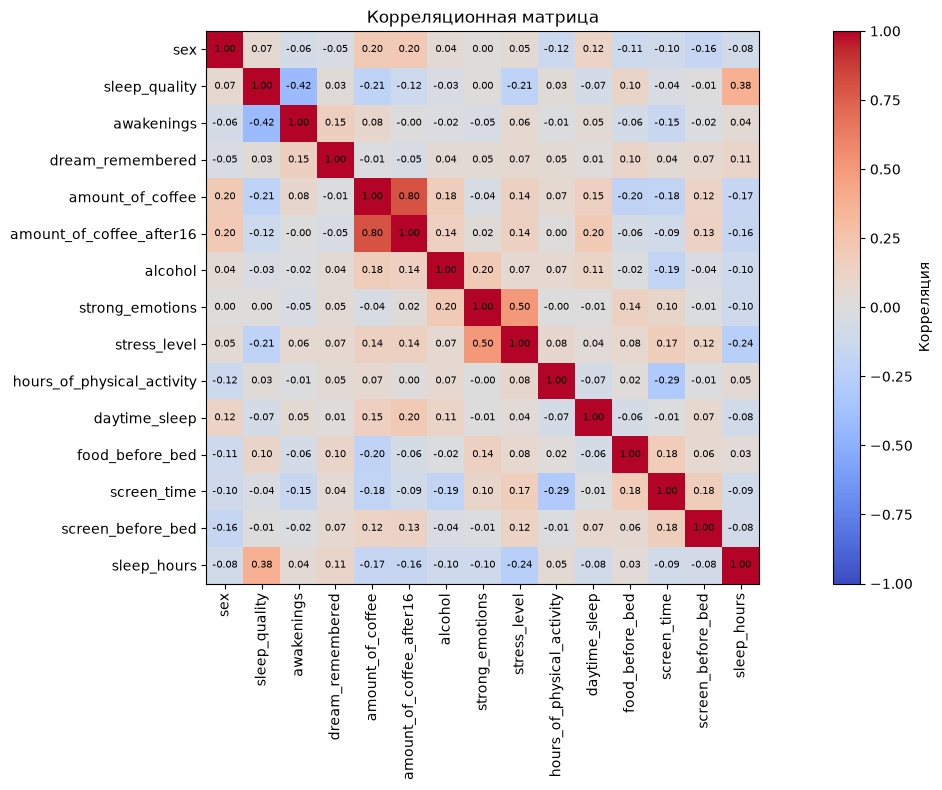

In [22]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, fontsize=10, rotation=90)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

В рассматриваемых числовых признаках не наблюдается заметной линейной ассоциации с таргетом. Это не исключает нелинейные зависимости, взаимодействия или влияние участника.

### Вывод по результатам общего EDA

На этапе первичного исследовательского анализа были рассмотрены распределения основных признаков и их различия между наблюдениями, в которых участник запомнил сон, и наблюдениями без воспоминания о сне.

В целом выраженных различий между двумя группами по большинству исследуемых признаков не обнаружено. При этом наблюдаются отдельные тенденции: в группе с воспоминанием о сне медианная продолжительность сна несколько выше, а также заметны небольшие различия по времени за экраном, употреблению алкоголя, приёму пищи перед сном и использованию экрана перед сном. Однако этих наблюдений недостаточно для вывода о наличии причинно-следственной связи.

Корреляционный анализ также не выявил выраженных линейных связей между числовыми признаками и целевой переменной. Это не исключает наличия нелинейных зависимостей или взаимодействия нескольких факторов.

Дополнительной особенностью набора данных является его повторная структура: один участник представлен несколькими наблюдениями за разные дни. Поэтому строки датасета нельзя считать полностью независимыми наблюдениями. Это необходимо учитывать на следующих этапах анализа и при построении моделей.

Таким образом, общий EDA позволил получить представление о структуре данных, распределениях признаков и возможных направлениях дальнейшего анализа. Следующим этапом является анализ панельной структуры данных, после чего можно перейти к подготовке признаков и построению моделей классификации для прогнозирования вероятности запоминания сна.

In [24]:
# Сохранение в csv
df.to_csv("../data/processed/after_eda.csv", index=False)